# Perceptron (PyTorch)

The Perceptron is the simplest neural unit: it computes a weighted sum of inputs,
adds a bias, and passes the result through an activation to make a binary decision.

`output = sigmoid(w . x + b)`

We train a single-layer perceptron to classify tumors as malignant/benign using the
**Breast Cancer Wisconsin** dataset (`sklearn.datasets.load_breast_cancer`), a small
real-world binary classification dataset.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)

In [2]:
# Load real dataset: 569 samples, 30 numeric features, binary target (malignant=0, benign=1)
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

X_train.shape, y_train.shape

(torch.Size([455, 30]), torch.Size([455, 1]))

In [3]:
class Perceptron(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)  # single neuron: w.x + b

    def forward(self, x):
        return self.linear(x)  # raw logit; sigmoid applied via loss/inference


model = Perceptron(X_train.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [4]:
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}")

epoch  20  loss 0.1883
epoch  40  loss 0.1415
epoch  60  loss 0.1218
epoch  80  loss 0.1105
epoch 100  loss 0.1029


Test accuracy: 0.956


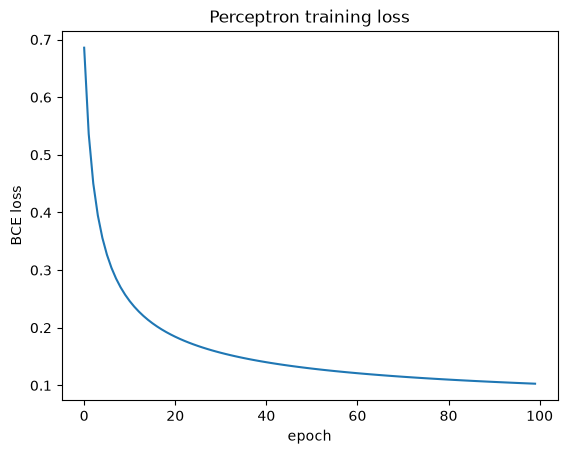

In [5]:
with torch.no_grad():
    preds = torch.sigmoid(model(X_test)) >= 0.5
    accuracy = (preds.float() == y_test).float().mean().item()

print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Perceptron training loss")
plt.show()